In [1]:
# ============================================================
# PHASE 7 — STATISTICAL EVIDENCE STRENGTHENING
# Confidence intervals + paired bootstrap comparison
# ============================================================

import os
import re
import json
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    auc
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 250)

SEED = 42
rng = np.random.default_rng(SEED)

# ============================================================
# PROJECT PATHS
# ============================================================

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

# Shared multimodal split from Phase 3
PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
PHASE3_DATA_DIR = PHASE3_DIR / "shared_dataset"
PHASE3_FEATURE_DIR = PHASE3_DIR / "features"
PHASE3_MODEL_DIR = PHASE3_DIR / "models"
PHASE3_RESULT_DIR = PHASE3_DIR / "results"

# Phase 4 prediction output for official Phase 3 model
PHASE4_DIR = PROJECT_DIR / "model" / "phase4_biological_validation_preparation"
PHASE4_RESULT_DIR = PHASE4_DIR / "results"

# Phase 5 DNABERT-2
PHASE5_DIR = PROJECT_DIR / "model" / "phase5_dnabert2_genomic_foundation"
PHASE5_EMBEDDING_DIR = PHASE5_DIR / "embeddings"
PHASE5_MODEL_DIR = PHASE5_DIR / "models"
PHASE5_RESULT_DIR = PHASE5_DIR / "results"

# Phase 5.4B biological quick validation
PHASE5_4B_DIR = PROJECT_DIR / "model" / "phase5_4B_dnabert2_biological_quick_validation"
PHASE5_4B_RESULT_DIR = PHASE5_4B_DIR / "results"

# New Phase 7 output
PHASE7_DIR = PROJECT_DIR / "model" / "phase7_statistical_evidence"
RESULT_DIR = PHASE7_DIR / "results"
FIGURE_DIR = PHASE7_DIR / "figures"
EXCEL_DIR = PHASE7_DIR / "excel"
REPORT_DIR = PHASE7_DIR / "reports"

for folder in [PHASE7_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 7 output:", PHASE7_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Phase 7 output: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence


In [2]:
# ============================================================
# LOAD TEST METADATA AND LABELS
# ============================================================

test_meta_path = PHASE3_DATA_DIR / "test_multimodal_metadata_v1.csv"
y_test_path = PHASE3_DATA_DIR / "y_test_multimodal_v1.npy"

assert test_meta_path.exists(), f"Missing: {test_meta_path}"
assert y_test_path.exists(), f"Missing: {y_test_path}"

test_meta = pd.read_csv(test_meta_path)
y_test = np.load(y_test_path).astype(int)

assert len(test_meta) == len(y_test), "test_meta and y_test length mismatch"

print("test_meta:", test_meta.shape)
print("y_test:", y_test.shape)
print("Label counts:")
print(pd.Series(y_test).value_counts().sort_index())

display(test_meta.head())

test_meta: (271, 12)
y_test: (271,)
Label counts:
0    136
1    135
Name: count, dtype: int64


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol
0,ENSG00000122971,ACADS,1,593,train,ACADS,1,1151,train,True,1,ACADS
1,ENSG00000162104,ADCY9,1,693,train,ADCY9,1,399,train,True,1,ADCY9
2,ENSG00000123146,ADGRE5,0,115,train,ADGRE5,0,880,train,True,0,ADGRE5
3,ENSG00000172594,SMPDL3A,0,1609,test,SMPDL3A,0,617,train,True,0,SMPDL3A
4,ENSG00000163116,STPG2,0,159,train,STPG2,0,207,train,True,0,STPG2


In [3]:
# ============================================================
# HELPER FUNCTIONS — SCORE LOADING
# ============================================================

def normalize_gene_id_series(s):
    return s.astype(str).str.strip()


def find_files(root_dir, patterns=None, suffixes=None):
    """
    Search files recursively.
    patterns: list of lowercase substrings that filename/path must contain.
    suffixes: list of allowed suffixes, e.g. ['.csv', '.pkl'].
    """
    root_dir = Path(root_dir)
    if not root_dir.exists():
        return []

    all_files = []
    for p in root_dir.rglob("*"):
        if not p.is_file():
            continue

        path_str = str(p).lower()
        name_str = p.name.lower()

        if suffixes is not None:
            if p.suffix.lower() not in suffixes:
                continue

        if patterns is not None:
            ok = all(pattern.lower() in path_str for pattern in patterns)
            if not ok:
                continue

        all_files.append(p)

    return sorted(all_files)


def infer_score_column(df, preferred_cols=None):
    """
    Infer positive-class score column from a prediction dataframe.
    """
    if preferred_cols is None:
        preferred_cols = [
            "score",
            "y_score",
            "probability",
            "positive_score",
            "positive_probability",
            "pred_score",
            "pred_proba",
            "proba_1",
            "prob_1",
            "phase5_score",
            "combined_svm_score",
            "protein_score",
            "protein_svm_score",
            "genomic_score",
            "genomic_svm_score",
            "rf_score",
            "svm_score",
            "lr_score",
        ]

    for col in preferred_cols:
        if col in df.columns:
            return col

    numeric_cols = [
        c for c in df.columns
        if pd.api.types.is_numeric_dtype(df[c])
    ]

    # Avoid label/pred/confusion columns
    blocked = {
        "label", "true_label", "y_true", "pred", "prediction",
        "tn", "fp", "fn", "tp", "rank", "phase5_rank"
    }

    numeric_cols = [
        c for c in numeric_cols
        if c.lower() not in blocked and "pred" not in c.lower()
    ]

    if len(numeric_cols) == 1:
        return numeric_cols[0]

    raise ValueError(
        f"Could not infer score column. Candidate numeric columns: {numeric_cols}. "
        f"Please specify score_col manually."
    )


def load_score_from_prediction_csv(
    csv_path,
    model_key,
    score_col=None,
    gene_id_col="gene_id",
    label_col_candidates=("true_label", "label", "y_true"),
):
    """
    Load model score from CSV and align with test_meta using gene_id if available.
    """
    csv_path = Path(csv_path)
    assert csv_path.exists(), f"Missing prediction CSV: {csv_path}"

    df = pd.read_csv(csv_path)

    if score_col is None:
        score_col = infer_score_column(df)

    assert score_col in df.columns, f"{score_col} not found in {csv_path}"

    out = pd.DataFrame()
    out["model_key"] = model_key

    if gene_id_col in df.columns and gene_id_col in test_meta.columns:
        tmp = df[[gene_id_col, score_col]].copy()
        tmp[gene_id_col] = normalize_gene_id_series(tmp[gene_id_col])

        base = test_meta[[gene_id_col]].copy()
        base[gene_id_col] = normalize_gene_id_series(base[gene_id_col])

        merged = base.merge(tmp, on=gene_id_col, how="left")

        missing = merged[score_col].isna().sum()
        if missing > 0:
            raise ValueError(
                f"Missing {missing} scores after gene_id merge for {model_key}. "
                f"CSV: {csv_path}"
            )

        score = merged[score_col].values.astype(float)

    else:
        if len(df) != len(test_meta):
            raise ValueError(
                f"No gene_id alignment possible and length mismatch for {model_key}: "
                f"CSV length={len(df)}, test length={len(test_meta)}"
            )

        score = df[score_col].values.astype(float)

    return score, {
        "model_key": model_key,
        "source_type": "csv",
        "source_path": str(csv_path),
        "score_col": score_col,
        "n": len(score)
    }


def get_positive_class_score(model, X):
    """
    Return positive class score/probability.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        # decision_function is valid for ROC/PR ranking.
        # For threshold classification, threshold 0 is usually used,
        # but here we only use these scores for ROC/PR bootstrap.
        return s

    return model.predict(X)


def load_score_from_model_and_features(
    model_path,
    X_path,
    model_key,
):
    """
    Load a saved sklearn model and X_test features, then compute scores.
    """
    model_path = Path(model_path)
    X_path = Path(X_path)

    assert model_path.exists(), f"Missing model: {model_path}"
    assert X_path.exists(), f"Missing features: {X_path}"

    model = joblib.load(model_path)
    X = np.load(X_path)

    assert X.shape[0] == len(y_test), (
        f"Feature rows mismatch for {model_key}: "
        f"X rows={X.shape[0]}, y_test={len(y_test)}"
    )

    score = get_positive_class_score(model, X).astype(float)

    return score, {
        "model_key": model_key,
        "source_type": "model+features",
        "model_path": str(model_path),
        "feature_path": str(X_path),
        "n": len(score)
    }

In [6]:
# ============================================================
# REGISTER MODEL SCORES — FIXED MANUAL VERSION (UPDATED)
# ============================================================
import numpy as np
import pandas as pd

score_dict = {}
score_sources = []

# ------------------------------------------------------------
# A. Protein-only ProtBERT-SW SVM
# ------------------------------------------------------------

protein_X_path = PHASE3_FEATURE_DIR / "X_test_protein_protbert_sw_v1.npy"

protein_model_path = (
    PHASE3_DIR
    / "phase3_1_modelling_light"
    / "models"
    / "phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl"
)

assert protein_X_path.exists(), f"Missing protein X: {protein_X_path}"
assert protein_model_path.exists(), f"Missing protein model: {protein_model_path}"

score, meta = load_score_from_model_and_features(
    model_path=protein_model_path,
    X_path=protein_X_path,
    model_key="Protein_only_ProtBERT_SW"
)

score_dict["Protein_only_ProtBERT_SW"] = score
score_sources.append(meta)

print("Loaded Protein-only:")
print("Model:", protein_model_path)
print("X:", protein_X_path)
print("Score shape:", score.shape)


# ------------------------------------------------------------
# B. Genomic-only K3/K4/Basic SVM (FIXED VIA AUTOMATIC SLICING)
# ------------------------------------------------------------

# Định nghĩa đường dẫn file Genomic sẽ được trích xuất
extracted_genomic_path = PHASE3_FEATURE_DIR / "X_test_genomic_k3k4basic_extracted_v1.npy"
combined_X_path = PHASE3_FEATURE_DIR / "X_test_combined_protein_genomic_v1.npy"

# Kiểm tra xem file trích xuất đã tồn tại từ trước chưa, nếu chưa thì tiến hành tách từ file Combined
if not extracted_genomic_path.exists():
    print("\n[Hệ thống] Không tìm thấy file Genomic độc lập. Tiến hành trích xuất từ file Combined...")
    assert combined_X_path.exists(), f"Không tìm thấy cả file dữ liệu gộp tại: {combined_X_path}"

    # Load file combined (1380 đặc trưng)
    X_combined = np.load(combined_X_path)

    # Cắt mảng: bỏ qua 1024 cột đầu của ProtBERT, lấy 356 cột sau của K3/K4/Basic
    X_genomic_only = X_combined[:, 1024:]

    # Lưu lại thành file npy độc lập phục vụ cho hàm load_score
    np.save(extracted_genomic_path, X_genomic_only)
    print(f"✅ Đã trích xuất thành công dữ liệu Genomic-only có kích thước: {X_genomic_only.shape}")

# Gán đường dẫn file đã trích xuất thành công vào biến xử lý
genomic_X_path = extracted_genomic_path

genomic_model_path = (
    PHASE3_DIR
    / "phase3_1_modelling_light"
    / "models"
    / "phase3_1_genomic_only_k3k4basic_svm_rbf_light.pkl"
)

assert genomic_model_path.exists(), f"Missing genomic model: {genomic_model_path}"

score, meta = load_score_from_model_and_features(
    model_path=genomic_model_path,
    X_path=genomic_X_path,
    model_key="Genomic_only_K3K4Basic"
)

score_dict["Genomic_only_K3K4Basic"] = score
score_sources.append(meta)

print("\nLoaded Genomic-only:")
print("Model:", genomic_model_path)
print("X:", genomic_X_path)
print("Score shape:", score.shape)


# ------------------------------------------------------------
# C. Multimodal handcrafted official Phase 3 model
# ------------------------------------------------------------

phase3_combined_pred_csv = (
    PHASE4_RESULT_DIR
    / "phase4_0B_official_combined_svm_all_test_predictions.csv"
)

assert phase3_combined_pred_csv.exists(), f"Missing: {phase3_combined_pred_csv}"

score, meta = load_score_from_prediction_csv(
    csv_path=phase3_combined_pred_csv,
    model_key="Multimodal_handcrafted",
    score_col="combined_svm_score"
)

score_dict["Multimodal_handcrafted"] = score
score_sources.append(meta)

print("\nLoaded Multimodal handcrafted:")
print("CSV:", phase3_combined_pred_csv)
print("Score shape:", score.shape)


# ------------------------------------------------------------
# D. Multimodal DNABERT-2 Phase 5 model
# ------------------------------------------------------------

phase5_dnabert2_pred_csv = (
    PHASE5_4B_RESULT_DIR
    / "phase5_4B_phase5_combined_dnabert2_all_test_predictions.csv"
)

assert phase5_dnabert2_pred_csv.exists(), f"Missing: {phase5_dnabert2_pred_csv}"

score, meta = load_score_from_prediction_csv(
    csv_path=phase5_dnabert2_pred_csv,
    model_key="Multimodal_DNABERT2",
    score_col="phase5_score"
)

score_dict["Multimodal_DNABERT2"] = score
score_sources.append(meta)

print("\nLoaded Multimodal DNABERT-2:")
print("CSV:", phase5_dnabert2_pred_csv)
print("Score shape:", score.shape)


# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------

required_models = [
    "Protein_only_ProtBERT_SW",
    "Genomic_only_K3K4Basic",
    "Multimodal_handcrafted",
    "Multimodal_DNABERT2",
]

print("\nLoaded models:")
for k in required_models:
    print(" -", k, score_dict[k].shape)

score_source_df = pd.DataFrame(score_sources)
display(score_source_df)

score_source_df.to_csv(
    RESULT_DIR / "phase7_score_sources.csv",
    index=False
)

Loaded Protein-only:
Model: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl
X: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_protein_protbert_sw_v1.npy
Score shape: (271,)

[Hệ thống] Không tìm thấy file Genomic độc lập. Tiến hành trích xuất từ file Combined...
✅ Đã trích xuất thành công dữ liệu Genomic-only có kích thước: (271, 356)

Loaded Genomic-only:
Model: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_genomic_only_k3k4basic_svm_rbf_light.pkl
X: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_genomic_k3k4basic_extracted_v1.npy
Score shape: (271,)

Loaded Multimodal handcrafted:
CSV: /content/drive/MyDrive/Project_Protein/model/phase4_biological_validation_preparation/results/phase4_0B_official_combined_svm_all_test_p

,model_key,source_type,model_path,feature_path,n,source_path,score_col
0,Protein_only_ProtBERT_SW,model+features,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_protein_protbert_sw_v1.npy,271,NaN,NaN
1,Genomic_only_K3K4Basic,model+features,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_genomic_only_k3k4basic_svm_rbf_light.pkl,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_genomic_k3k4basic_extracted_v1.npy,271,NaN,NaN
2,Multimodal_handcrafted,csv,NaN,NaN,271,/content/drive/MyDrive/Project_Protein/model/phase4_biological_validation_preparation/results/phase4_0B_official_combined_svm_all_test_predictions.csv,combined_svm_score
3,Multimodal_DNABERT2,csv,NaN,NaN,271,/content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_phase5_combined_dnabert2_all_test_predictions.csv,phase5_score


In [7]:
# ============================================================
# BUILD UNIFIED SCORE TABLE
# ============================================================

score_table_df = test_meta.copy()
score_table_df["true_label"] = y_test

for model_key, score in score_dict.items():
    assert len(score) == len(score_table_df), f"Length mismatch for {model_key}"
    score_table_df[f"{model_key}_score"] = score

display(score_table_df.head())

score_table_path = RESULT_DIR / "phase7_unified_model_scores.csv"
score_table_df.to_csv(score_table_path, index=False)

print("Saved:", score_table_path)

,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score
0,ENSG00000122971,ACADS,1,593,train,ACADS,1,1151,train,True,1,ACADS,1,0.719627,0.546326,0.750810,0.744279
1,ENSG00000162104,ADCY9,1,693,train,ADCY9,1,399,train,True,1,ADCY9,1,0.680303,0.625282,0.756812,0.791051
2,ENSG00000123146,ADGRE5,0,115,train,ADGRE5,0,880,train,True,0,ADGRE5,0,0.554474,0.500000,0.532796,0.519103
3,ENSG00000172594,SMPDL3A,0,1609,test,SMPDL3A,0,617,train,True,0,SMPDL3A,0,0.683032,0.637262,0.690366,0.570216
4,ENSG00000163116,STPG2,0,159,train,STPG2,0,207,train,True,0,STPG2,0,0.237920,0.404538,0.235603,0.278157


Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_unified_model_scores.csv


In [8]:
# ============================================================
# METRIC HELPERS
# ============================================================

def classification_metrics_from_score(y_true, y_score, threshold=0.5):
    """
    Classification metrics at threshold.
    If scores are SVM decision_function and not calibrated probability,
    threshold=0.5 may not be valid. For ROC/PR, score ranking is fine.
    """
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_pr_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def metric_value(y_true, y_score, metric_name):
    if metric_name == "roc_auc":
        return safe_roc_auc(y_true, y_score)
    if metric_name == "pr_auc":
        return safe_pr_auc(y_true, y_score)
    raise ValueError("Unsupported metric_name")

In [9]:
# ============================================================
# BOOTSTRAP CONFIDENCE INTERVAL
# ============================================================

N_BOOTSTRAP = 5000
CI_LOW = 2.5
CI_HIGH = 97.5

def bootstrap_metric_ci(
    y_true,
    y_score,
    metric_name="roc_auc",
    n_bootstrap=5000,
    ci_low=2.5,
    ci_high=97.5,
    random_state=42
):
    """
    Nonparametric bootstrap CI for ROC-AUC or PR-AUC.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    rng_local = np.random.default_rng(random_state)
    n = len(y_true)

    observed = metric_value(y_true, y_score, metric_name)

    boot_values = []

    for _ in range(n_bootstrap):
        idx = rng_local.integers(0, n, size=n)
        y_b = y_true[idx]
        s_b = y_score[idx]

        if len(np.unique(y_b)) < 2:
            continue

        v = metric_value(y_b, s_b, metric_name)

        if not np.isnan(v):
            boot_values.append(v)

    boot_values = np.asarray(boot_values)

    return {
        "metric": metric_name,
        "observed": observed,
        "ci_lower": np.percentile(boot_values, ci_low),
        "ci_upper": np.percentile(boot_values, ci_high),
        "bootstrap_mean": np.mean(boot_values),
        "bootstrap_std": np.std(boot_values),
        "n_bootstrap_valid": len(boot_values)
    }


ci_records = []

for model_key, score in score_dict.items():
    for metric_name in ["roc_auc", "pr_auc"]:
        out = bootstrap_metric_ci(
            y_true=y_test,
            y_score=score,
            metric_name=metric_name,
            n_bootstrap=N_BOOTSTRAP,
            ci_low=CI_LOW,
            ci_high=CI_HIGH,
            random_state=SEED
        )

        out["model_key"] = model_key
        ci_records.append(out)

ci_df = pd.DataFrame(ci_records)

ci_df = ci_df[[
    "model_key",
    "metric",
    "observed",
    "ci_lower",
    "ci_upper",
    "bootstrap_mean",
    "bootstrap_std",
    "n_bootstrap_valid"
]]

ci_df = ci_df.sort_values(
    by=["metric", "observed"],
    ascending=[True, False]
).reset_index(drop=True)

for col in ["observed", "ci_lower", "ci_upper", "bootstrap_mean", "bootstrap_std"]:
    ci_df[col] = ci_df[col].round(4)

display(ci_df)

ci_path = RESULT_DIR / "phase7_roc_pr_auc_bootstrap_95ci.csv"
ci_df.to_csv(ci_path, index=False)

print("Saved:", ci_path)

,model_key,metric,observed,ci_lower,ci_upper,bootstrap_mean,bootstrap_std,n_bootstrap_valid
0,Multimodal_handcrafted,pr_auc,0.7573,0.6893,0.8212,0.7589,0.0336,5000
1,Multimodal_DNABERT2,pr_auc,0.7447,0.6692,0.8225,0.7476,0.0395,5000
2,Protein_only_ProtBERT_SW,pr_auc,0.7433,0.6675,0.8175,0.7459,0.0388,5000
3,Genomic_only_K3K4Basic,pr_auc,0.6215,0.5386,0.7124,0.6263,0.0441,5000
4,Multimodal_DNABERT2,roc_auc,0.7568,0.7002,0.8108,0.7566,0.0287,5000
5,Multimodal_handcrafted,roc_auc,0.7290,0.6707,0.7857,0.7290,0.0298,5000
6,Protein_only_ProtBERT_SW,roc_auc,0.7274,0.6677,0.7858,0.7273,0.0306,5000
7,Genomic_only_K3K4Basic,roc_auc,0.6397,0.5722,0.7045,0.6395,0.0336,5000


Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_roc_pr_auc_bootstrap_95ci.csv


In [10]:
# ============================================================
# CLASSIFICATION METRICS AT DEFAULT THRESHOLD
# ============================================================
# Note:
# For calibrated probabilities, threshold 0.5 is meaningful.
# For SVM decision_function scores, threshold 0.0 may be more appropriate.
# If your saved SVM score is predict_proba[:,1], use 0.5.
# If your saved SVM score is decision_function, change threshold manually.

DEFAULT_THRESHOLDS = {
    "Protein_only_ProtBERT_SW": 0.5,
    "Genomic_only_K3K4Basic": 0.5,
    "Multimodal_handcrafted": 0.5,
    "Multimodal_DNABERT2": 0.5,
}

classif_records = []

for model_key, score in score_dict.items():
    threshold = DEFAULT_THRESHOLDS.get(model_key, 0.5)
    metrics = classification_metrics_from_score(
        y_true=y_test,
        y_score=score,
        threshold=threshold
    )

    metrics["model_key"] = model_key
    classif_records.append(metrics)

classification_df = pd.DataFrame(classif_records)

cols = [
    "model_key",
    "threshold",
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "mcc",
    "tn",
    "fp",
    "fn",
    "tp"
]

classification_df = classification_df[cols]

for col in ["accuracy", "precision", "recall_sensitivity", "specificity", "f1", "mcc"]:
    classification_df[col] = classification_df[col].round(4)

display(classification_df)

classification_path = RESULT_DIR / "phase7_classification_metrics_default_threshold.csv"
classification_df.to_csv(classification_path, index=False)

print("Saved:", classification_path)

,model_key,threshold,accuracy,precision,recall_sensitivity,specificity,f1,mcc,tn,fp,fn,tp
0,Protein_only_ProtBERT_SW,0.5,0.6605,0.6525,0.6815,0.6397,0.6667,0.3215,87,49,43,92
1,Genomic_only_K3K4Basic,0.5,0.5683,0.5763,0.5037,0.6324,0.5375,0.1372,86,50,67,68
2,Multimodal_handcrafted,0.5,0.6716,0.6825,0.6370,0.7059,0.6590,0.3438,96,40,49,86
3,Multimodal_DNABERT2,0.5,0.6716,0.6769,0.6519,0.6912,0.6642,0.3433,94,42,47,88


Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_classification_metrics_default_threshold.csv


In [11]:
# ============================================================
# PAIRED BOOTSTRAP COMPARISON
# ============================================================

def paired_bootstrap_delta(
    y_true,
    score_a,
    score_b,
    model_a,
    model_b,
    metric_name="roc_auc",
    n_bootstrap=5000,
    ci_low=2.5,
    ci_high=97.5,
    random_state=42
):
    """
    Paired bootstrap comparison:
    delta = metric(model_b) - metric(model_a)
    Same bootstrap sample indices are used for both models.
    """
    y_true = np.asarray(y_true).astype(int)
    score_a = np.asarray(score_a).astype(float)
    score_b = np.asarray(score_b).astype(float)

    rng_local = np.random.default_rng(random_state)
    n = len(y_true)

    obs_a = metric_value(y_true, score_a, metric_name)
    obs_b = metric_value(y_true, score_b, metric_name)
    obs_delta = obs_b - obs_a

    deltas = []

    for _ in range(n_bootstrap):
        idx = rng_local.integers(0, n, size=n)

        y_b = y_true[idx]

        if len(np.unique(y_b)) < 2:
            continue

        a_b = metric_value(y_b, score_a[idx], metric_name)
        b_b = metric_value(y_b, score_b[idx], metric_name)

        if not np.isnan(a_b) and not np.isnan(b_b):
            deltas.append(b_b - a_b)

    deltas = np.asarray(deltas)

    ci_l = np.percentile(deltas, ci_low)
    ci_u = np.percentile(deltas, ci_high)

    # Two-sided bootstrap p-value for H0: delta = 0
    p_left = np.mean(deltas <= 0)
    p_right = np.mean(deltas >= 0)
    p_two_sided = 2 * min(p_left, p_right)
    p_two_sided = min(p_two_sided, 1.0)

    return {
        "metric": metric_name,
        "model_a": model_a,
        "model_b": model_b,
        "metric_a": obs_a,
        "metric_b": obs_b,
        "delta_b_minus_a": obs_delta,
        "delta_ci_lower": ci_l,
        "delta_ci_upper": ci_u,
        "p_value_bootstrap_two_sided": p_two_sided,
        "n_bootstrap_valid": len(deltas),
        "interpretation": (
            "significant" if (ci_l > 0 or ci_u < 0) else "not_significant_or_uncertain"
        )
    }


pairwise_records = []

model_keys = list(score_dict.keys())

# All pairwise comparisons
for model_a, model_b in combinations(model_keys, 2):
    for metric_name in ["roc_auc", "pr_auc"]:
        out = paired_bootstrap_delta(
            y_true=y_test,
            score_a=score_dict[model_a],
            score_b=score_dict[model_b],
            model_a=model_a,
            model_b=model_b,
            metric_name=metric_name,
            n_bootstrap=N_BOOTSTRAP,
            ci_low=CI_LOW,
            ci_high=CI_HIGH,
            random_state=SEED
        )
        pairwise_records.append(out)

pairwise_df = pd.DataFrame(pairwise_records)

for col in [
    "metric_a",
    "metric_b",
    "delta_b_minus_a",
    "delta_ci_lower",
    "delta_ci_upper",
    "p_value_bootstrap_two_sided"
]:
    pairwise_df[col] = pairwise_df[col].round(4)

pairwise_df = pairwise_df.sort_values(
    by=["metric", "model_a", "model_b"]
).reset_index(drop=True)

display(pairwise_df)

pairwise_path = RESULT_DIR / "phase7_pairwise_paired_bootstrap_comparisons.csv"
pairwise_df.to_csv(pairwise_path, index=False)

print("Saved:", pairwise_path)

,metric,model_a,model_b,metric_a,metric_b,delta_b_minus_a,delta_ci_lower,delta_ci_upper,p_value_bootstrap_two_sided,n_bootstrap_valid,interpretation
0,pr_auc,Genomic_only_K3K4Basic,Multimodal_DNABERT2,0.6215,0.7447,0.1232,0.0541,0.1913,0.0008,5000,significant
1,pr_auc,Genomic_only_K3K4Basic,Multimodal_handcrafted,0.6215,0.7573,0.1357,0.0678,0.1985,0.0000,5000,significant
2,pr_auc,Multimodal_handcrafted,Multimodal_DNABERT2,0.7573,0.7447,-0.0126,-0.0552,0.0298,0.5980,5000,not_significant_or_uncertain
3,pr_auc,Protein_only_ProtBERT_SW,Genomic_only_K3K4Basic,0.7433,0.6215,-0.1218,-0.2060,-0.0324,0.0084,5000,significant
4,pr_auc,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,0.7433,0.7447,0.0013,-0.0589,0.0638,0.9580,5000,not_significant_or_uncertain
5,pr_auc,Protein_only_ProtBERT_SW,Multimodal_handcrafted,0.7433,0.7573,0.0139,-0.0281,0.0566,0.5428,5000,not_significant_or_uncertain
6,roc_auc,Genomic_only_K3K4Basic,Multimodal_DNABERT2,0.6397,0.7568,0.1171,0.0528,0.1842,0.0004,5000,significant
7,roc_auc,Genomic_only_K3K4Basic,Multimodal_handcrafted,0.6397,0.7290,0.0893,0.0270,0.1518,0.0060,5000,significant
8,roc_auc,Multimodal_handcrafted,Multimodal_DNABERT2,0.7290,0.7568,0.0278,0.0015,0.0540,0.0396,5000,significant
9,roc_auc,Protein_only_ProtBERT_SW,Genomic_only_K3K4Basic,0.7274,0.6397,-0.0877,-0.1678,-0.0078,0.0348,5000,significant


Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_pairwise_paired_bootstrap_comparisons.csv


In [12]:
# ============================================================
# FOCUSED COMPARISONS REQUESTED BY PROFESSOR
# ============================================================

focused_pairs = [
    ("Protein_only_ProtBERT_SW", "Multimodal_handcrafted"),
    ("Genomic_only_K3K4Basic", "Multimodal_handcrafted"),
    ("Protein_only_ProtBERT_SW", "Multimodal_DNABERT2"),
    ("Genomic_only_K3K4Basic", "Multimodal_DNABERT2"),
    ("Multimodal_handcrafted", "Multimodal_DNABERT2"),
]

focused_records = []

for model_a, model_b in focused_pairs:
    if model_a not in score_dict or model_b not in score_dict:
        continue

    for metric_name in ["roc_auc", "pr_auc"]:
        out = paired_bootstrap_delta(
            y_true=y_test,
            score_a=score_dict[model_a],
            score_b=score_dict[model_b],
            model_a=model_a,
            model_b=model_b,
            metric_name=metric_name,
            n_bootstrap=N_BOOTSTRAP,
            ci_low=CI_LOW,
            ci_high=CI_HIGH,
            random_state=SEED
        )
        focused_records.append(out)

focused_comparison_df = pd.DataFrame(focused_records)

for col in [
    "metric_a",
    "metric_b",
    "delta_b_minus_a",
    "delta_ci_lower",
    "delta_ci_upper",
    "p_value_bootstrap_two_sided"
]:
    focused_comparison_df[col] = focused_comparison_df[col].round(4)

display(focused_comparison_df)

focused_path = RESULT_DIR / "phase7_focused_model_comparisons_for_professor.csv"
focused_comparison_df.to_csv(focused_path, index=False)

print("Saved:", focused_path)

,metric,model_a,model_b,metric_a,metric_b,delta_b_minus_a,delta_ci_lower,delta_ci_upper,p_value_bootstrap_two_sided,n_bootstrap_valid,interpretation
0,roc_auc,Protein_only_ProtBERT_SW,Multimodal_handcrafted,0.7274,0.7290,0.0016,-0.0287,0.0316,0.9120,5000,not_significant_or_uncertain
1,pr_auc,Protein_only_ProtBERT_SW,Multimodal_handcrafted,0.7433,0.7573,0.0139,-0.0281,0.0566,0.5428,5000,not_significant_or_uncertain
2,roc_auc,Genomic_only_K3K4Basic,Multimodal_handcrafted,0.6397,0.7290,0.0893,0.0270,0.1518,0.0060,5000,significant
3,pr_auc,Genomic_only_K3K4Basic,Multimodal_handcrafted,0.6215,0.7573,0.1357,0.0678,0.1985,0.0000,5000,significant
4,roc_auc,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,0.7274,0.7568,0.0294,-0.0099,0.0692,0.1284,5000,not_significant_or_uncertain
5,pr_auc,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,0.7433,0.7447,0.0013,-0.0589,0.0638,0.9580,5000,not_significant_or_uncertain
6,roc_auc,Genomic_only_K3K4Basic,Multimodal_DNABERT2,0.6397,0.7568,0.1171,0.0528,0.1842,0.0004,5000,significant
7,pr_auc,Genomic_only_K3K4Basic,Multimodal_DNABERT2,0.6215,0.7447,0.1232,0.0541,0.1913,0.0008,5000,significant
8,roc_auc,Multimodal_handcrafted,Multimodal_DNABERT2,0.7290,0.7568,0.0278,0.0015,0.0540,0.0396,5000,significant
9,pr_auc,Multimodal_handcrafted,Multimodal_DNABERT2,0.7573,0.7447,-0.0126,-0.0552,0.0298,0.5980,5000,not_significant_or_uncertain


Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_focused_model_comparisons_for_professor.csv


In [13]:
# ============================================================
# COMBINED SUMMARY TABLE
# ============================================================

roc_ci = ci_df[ci_df["metric"] == "roc_auc"].copy()
pr_ci = ci_df[ci_df["metric"] == "pr_auc"].copy()

roc_ci = roc_ci.rename(columns={
    "observed": "roc_auc",
    "ci_lower": "roc_auc_ci_lower",
    "ci_upper": "roc_auc_ci_upper"
})[["model_key", "roc_auc", "roc_auc_ci_lower", "roc_auc_ci_upper"]]

pr_ci = pr_ci.rename(columns={
    "observed": "pr_auc",
    "ci_lower": "pr_auc_ci_lower",
    "ci_upper": "pr_auc_ci_upper"
})[["model_key", "pr_auc", "pr_auc_ci_lower", "pr_auc_ci_upper"]]

summary_df = (
    roc_ci
    .merge(pr_ci, on="model_key", how="inner")
    .merge(classification_df, on="model_key", how="left")
)

summary_df = summary_df.sort_values(
    by=["roc_auc", "pr_auc", "mcc"],
    ascending=False
).reset_index(drop=True)

display(summary_df)

summary_path = RESULT_DIR / "phase7_model_performance_summary_with_95ci.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

,model_key,roc_auc,roc_auc_ci_lower,roc_auc_ci_upper,pr_auc,pr_auc_ci_lower,pr_auc_ci_upper,threshold,accuracy,precision,recall_sensitivity,specificity,f1,mcc,tn,fp,fn,tp
0,Multimodal_DNABERT2,0.7568,0.7002,0.8108,0.7447,0.6692,0.8225,0.5,0.6716,0.6769,0.6519,0.6912,0.6642,0.3433,94,42,47,88
1,Multimodal_handcrafted,0.7290,0.6707,0.7857,0.7573,0.6893,0.8212,0.5,0.6716,0.6825,0.6370,0.7059,0.6590,0.3438,96,40,49,86
2,Protein_only_ProtBERT_SW,0.7274,0.6677,0.7858,0.7433,0.6675,0.8175,0.5,0.6605,0.6525,0.6815,0.6397,0.6667,0.3215,87,49,43,92
3,Genomic_only_K3K4Basic,0.6397,0.5722,0.7045,0.6215,0.5386,0.7124,0.5,0.5683,0.5763,0.5037,0.6324,0.5375,0.1372,86,50,67,68


Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_model_performance_summary_with_95ci.csv


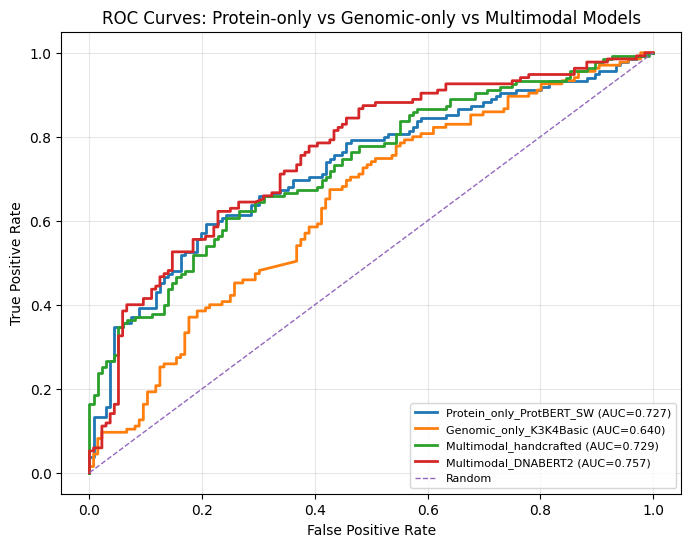

Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_roc_curve_comparison.png


In [14]:
# ============================================================
# ROC CURVE COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

for model_key, score in score_dict.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    roc_auc = roc_auc_score(y_test, score)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_key} (AUC={roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Protein-only vs Genomic-only vs Multimodal Models")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)

roc_fig_path = FIGURE_DIR / "phase7_roc_curve_comparison.png"
plt.savefig(roc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", roc_fig_path)

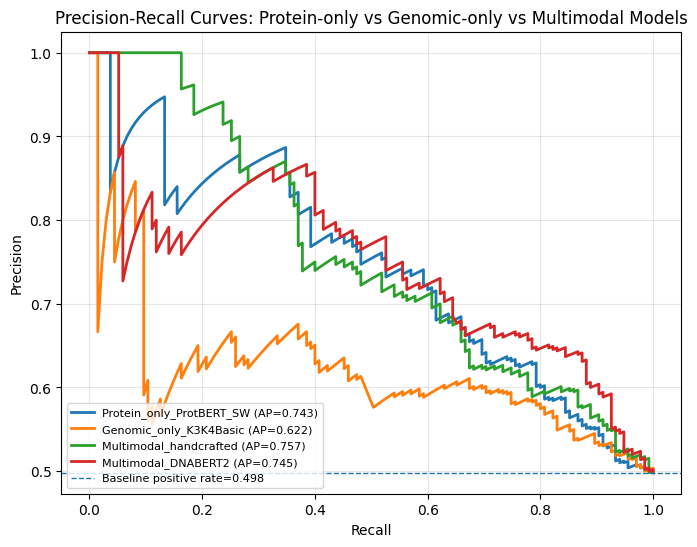

Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_pr_curve_comparison.png


In [15]:
# ============================================================
# PRECISION-RECALL CURVE COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

positive_rate = np.mean(y_test)

for model_key, score in score_dict.items():
    precision, recall, _ = precision_recall_curve(y_test, score)
    pr_auc = average_precision_score(y_test, score)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_key} (AP={pr_auc:.3f})"
    )

plt.axhline(
    positive_rate,
    linestyle="--",
    linewidth=1,
    label=f"Baseline positive rate={positive_rate:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves: Protein-only vs Genomic-only vs Multimodal Models")
plt.legend(loc="lower left", fontsize=8)
plt.grid(alpha=0.3)

pr_fig_path = FIGURE_DIR / "phase7_pr_curve_comparison.png"
plt.savefig(pr_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pr_fig_path)

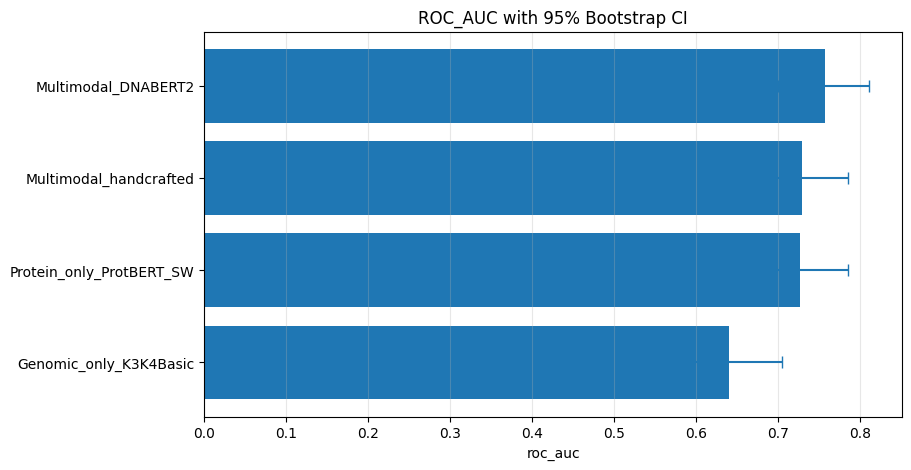

Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_roc_auc_95ci_barplot.png


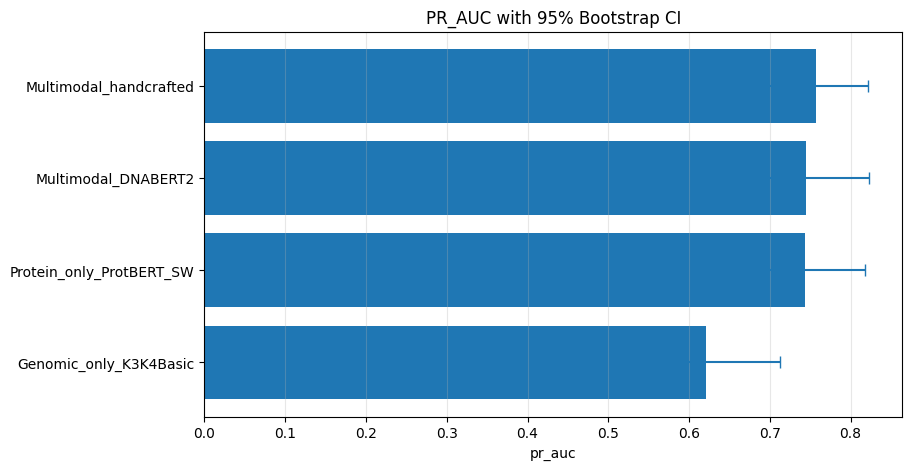

Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_pr_auc_95ci_barplot.png


In [16]:
# ============================================================
# METRIC CI BAR PLOTS
# ============================================================

def plot_metric_with_ci(summary_df, metric, ci_lower, ci_upper, output_path):
    plot_df = summary_df.sort_values(metric, ascending=True).copy()

    x = plot_df[metric].values
    labels = plot_df["model_key"].values

    lower_err = x - plot_df[ci_lower].values
    upper_err = plot_df[ci_upper].values - x
    xerr = np.vstack([lower_err, upper_err])

    plt.figure(figsize=(9, 5))
    plt.barh(labels, x)
    plt.errorbar(
        x,
        np.arange(len(labels)),
        xerr=xerr,
        fmt="none",
        capsize=4
    )

    plt.xlabel(metric)
    plt.title(f"{metric.upper()} with 95% Bootstrap CI")
    plt.grid(axis="x", alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


plot_metric_with_ci(
    summary_df=summary_df,
    metric="roc_auc",
    ci_lower="roc_auc_ci_lower",
    ci_upper="roc_auc_ci_upper",
    output_path=FIGURE_DIR / "phase7_roc_auc_95ci_barplot.png"
)

plot_metric_with_ci(
    summary_df=summary_df,
    metric="pr_auc",
    ci_lower="pr_auc_ci_lower",
    ci_upper="pr_auc_ci_upper",
    output_path=FIGURE_DIR / "phase7_pr_auc_95ci_barplot.png"
)

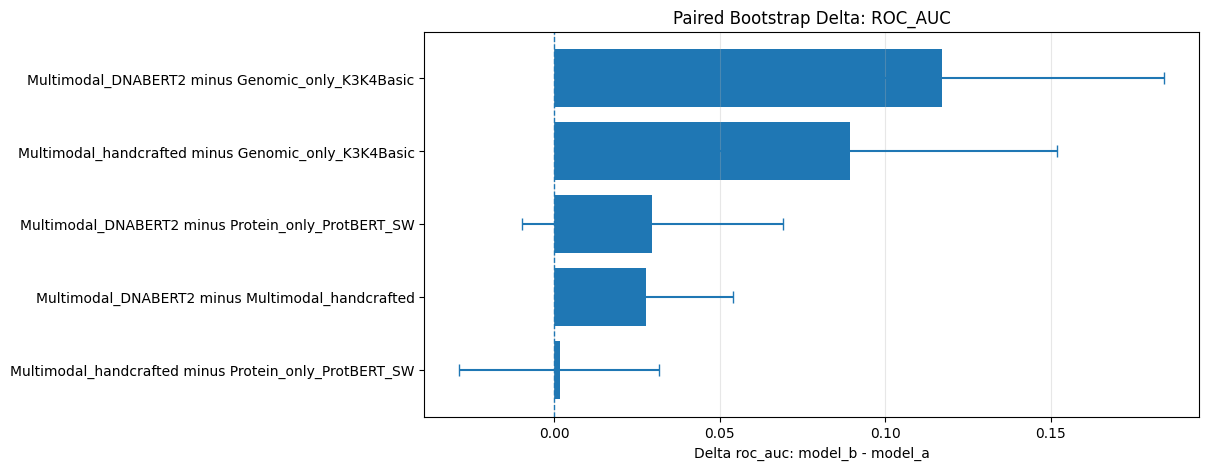

Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_focused_delta_roc_auc_95ci.png


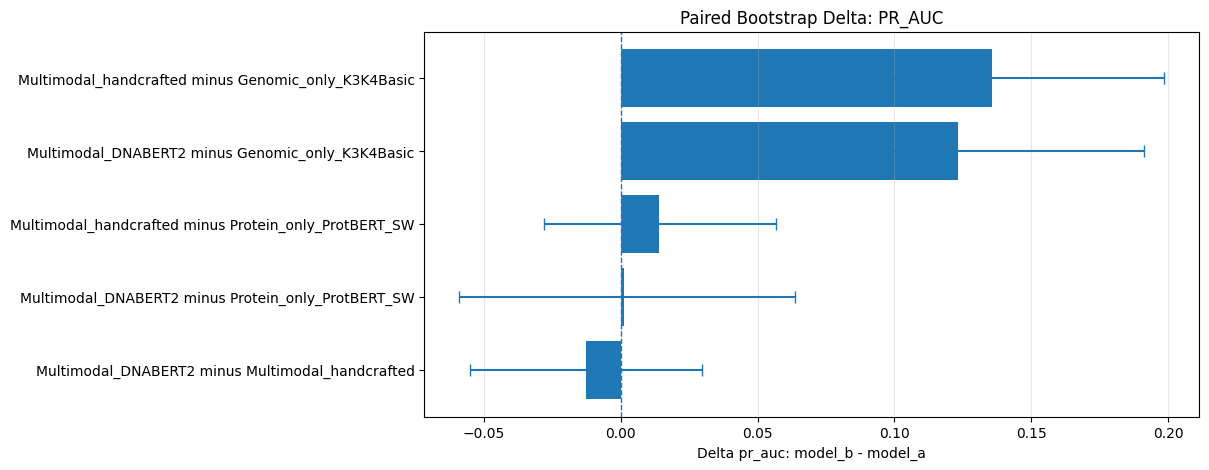

Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_focused_delta_pr_auc_95ci.png


In [17]:
# ============================================================
# PAIRWISE DELTA PLOT FOR FOCUSED COMPARISONS
# ============================================================

def plot_pairwise_delta(df, metric_name, output_path):
    plot_df = df[df["metric"] == metric_name].copy()

    plot_df["comparison"] = (
        plot_df["model_b"] + " minus " + plot_df["model_a"]
    )

    plot_df = plot_df.sort_values("delta_b_minus_a", ascending=True)

    x = plot_df["delta_b_minus_a"].values
    labels = plot_df["comparison"].values

    lower_err = x - plot_df["delta_ci_lower"].values
    upper_err = plot_df["delta_ci_upper"].values - x
    xerr = np.vstack([lower_err, upper_err])

    plt.figure(figsize=(10, max(5, 0.55 * len(plot_df))))
    plt.barh(labels, x)
    plt.errorbar(
        x,
        np.arange(len(labels)),
        xerr=xerr,
        fmt="none",
        capsize=4
    )

    plt.axvline(0, linestyle="--", linewidth=1)

    plt.xlabel(f"Delta {metric_name}: model_b - model_a")
    plt.title(f"Paired Bootstrap Delta: {metric_name.upper()}")
    plt.grid(axis="x", alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


plot_pairwise_delta(
    focused_comparison_df,
    metric_name="roc_auc",
    output_path=FIGURE_DIR / "phase7_focused_delta_roc_auc_95ci.png"
)

plot_pairwise_delta(
    focused_comparison_df,
    metric_name="pr_auc",
    output_path=FIGURE_DIR / "phase7_focused_delta_pr_auc_95ci.png"
)

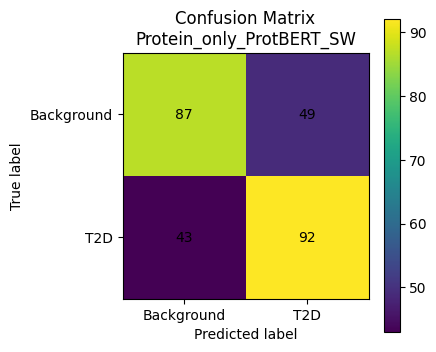

Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_confusion_matrix_Protein_only_ProtBERT_SW.png


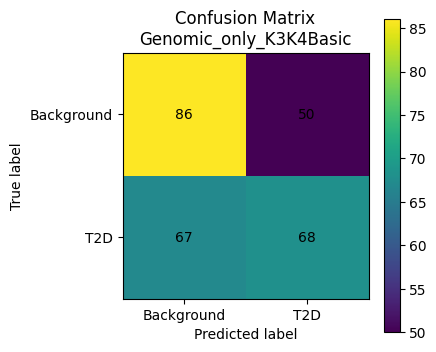

Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_confusion_matrix_Genomic_only_K3K4Basic.png


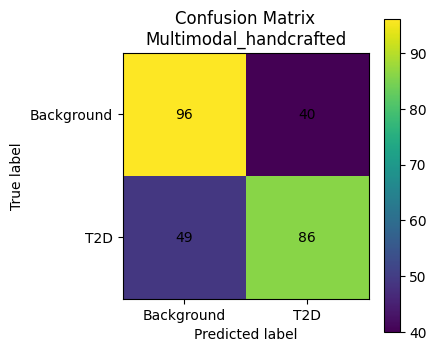

Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_confusion_matrix_Multimodal_handcrafted.png


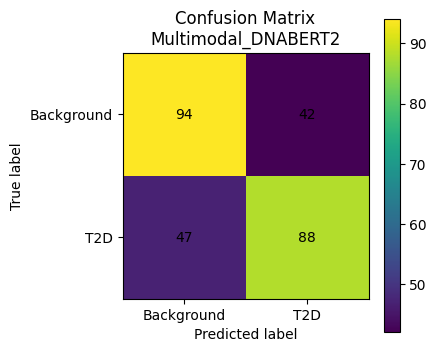

Saved: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_confusion_matrix_Multimodal_DNABERT2.png


In [18]:
# ============================================================
# CONFUSION MATRIX FIGURES
# ============================================================

def plot_confusion_matrix_simple(y_true, y_score, model_key, threshold=0.5, output_path=None):
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix\n{model_key}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    plt.xticks([0, 1], ["Background", "T2D"])
    plt.yticks([0, 1], ["Background", "T2D"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

    if output_path is not None:
        print("Saved:", output_path)


for model_key, score in score_dict.items():
    threshold = DEFAULT_THRESHOLDS.get(model_key, 0.5)
    out_path = FIGURE_DIR / f"phase7_confusion_matrix_{model_key}.png"

    plot_confusion_matrix_simple(
        y_true=y_test,
        y_score=score,
        model_key=model_key,
        threshold=threshold,
        output_path=out_path
    )

In [19]:
# ============================================================
# SAVE EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase7_statistical_evidence_tables.xlsx"

tables_to_save = {
    "score_sources": score_source_df,
    "performance_95ci": summary_df,
    "roc_pr_ci_long": ci_df,
    "classification_metrics": classification_df,
    "pairwise_all": pairwise_df,
    "focused_comparisons": focused_comparison_df,
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables_to_save.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/excel/phase7_statistical_evidence_tables.xlsx


In [20]:
# ============================================================
# AUTO-GENERATE PHASE 7 REPORT SUMMARY
# ============================================================

best_roc_row = summary_df.sort_values("roc_auc", ascending=False).iloc[0]
best_pr_row = summary_df.sort_values("pr_auc", ascending=False).iloc[0]

# Focused comparison: DNABERT2 vs handcrafted multimodal
dnabert_vs_handcrafted = focused_comparison_df[
    (focused_comparison_df["model_a"] == "Multimodal_handcrafted") &
    (focused_comparison_df["model_b"] == "Multimodal_DNABERT2")
].copy()

report_lines = []

report_lines.append("# Phase 7 — Statistical Evidence Strengthening Report\n")
report_lines.append("## Objective\n")
report_lines.append(
    "This phase estimated uncertainty around model performance using nonparametric bootstrap "
    "confidence intervals and paired bootstrap comparisons. The goal was to evaluate whether "
    "observed differences between protein-only, genomic-only, handcrafted multimodal, and "
    "DNABERT-2 multimodal models are meaningful on the same held-out test set.\n"
)

report_lines.append("## Best Models by Ranking Metrics\n")
report_lines.append(
    f"- Best ROC-AUC model: **{best_roc_row['model_key']}**, "
    f"ROC-AUC = {best_roc_row['roc_auc']:.4f} "
    f"[{best_roc_row['roc_auc_ci_lower']:.4f}, {best_roc_row['roc_auc_ci_upper']:.4f}].\n"
)
report_lines.append(
    f"- Best PR-AUC model: **{best_pr_row['model_key']}**, "
    f"PR-AUC = {best_pr_row['pr_auc']:.4f} "
    f"[{best_pr_row['pr_auc_ci_lower']:.4f}, {best_pr_row['pr_auc_ci_upper']:.4f}].\n"
)

report_lines.append("## Focused Comparison: DNABERT-2 Multimodal vs Handcrafted Multimodal\n")

if not dnabert_vs_handcrafted.empty:
    for _, row in dnabert_vs_handcrafted.iterrows():
        report_lines.append(
            f"- {row['metric']}: delta = {row['delta_b_minus_a']:.4f}, "
            f"95% CI [{row['delta_ci_lower']:.4f}, {row['delta_ci_upper']:.4f}], "
            f"bootstrap p = {row['p_value_bootstrap_two_sided']:.4f}, "
            f"interpretation = {row['interpretation']}.\n"
        )
else:
    report_lines.append(
        "- DNABERT-2 vs handcrafted multimodal focused comparison was not found.\n"
    )

report_lines.append("\n## Interpretation Guide\n")
report_lines.append(
    "If a pairwise delta confidence interval includes zero, the difference should be interpreted "
    "as uncertain or not statistically robust under bootstrap resampling. If the interval excludes "
    "zero, the improvement is more strongly supported. ROC-AUC and PR-AUC are threshold-independent, "
    "while F1 and MCC depend on the selected classification threshold.\n"
)

report_text = "\n".join(report_lines)

report_path = REPORT_DIR / "phase7_statistical_evidence_summary.md"

with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print("Saved report:", report_path)

# Phase 7 — Statistical Evidence Strengthening Report

## Objective

This phase estimated uncertainty around model performance using nonparametric bootstrap confidence intervals and paired bootstrap comparisons. The goal was to evaluate whether observed differences between protein-only, genomic-only, handcrafted multimodal, and DNABERT-2 multimodal models are meaningful on the same held-out test set.

## Best Models by Ranking Metrics

- Best ROC-AUC model: **Multimodal_DNABERT2**, ROC-AUC = 0.7568 [0.7002, 0.8108].

- Best PR-AUC model: **Multimodal_handcrafted**, PR-AUC = 0.7573 [0.6893, 0.8212].

## Focused Comparison: DNABERT-2 Multimodal vs Handcrafted Multimodal

- roc_auc: delta = 0.0278, 95% CI [0.0015, 0.0540], bootstrap p = 0.0396, interpretation = significant.

- pr_auc: delta = -0.0126, 95% CI [-0.0552, 0.0298], bootstrap p = 0.5980, interpretation = not_significant_or_uncertain.


## Interpretation Guide

If a pairwise delta confidence interval includes zero, the differenc

In [21]:
# ============================================================
# LIST OUTPUT FILES
# ============================================================

print("=== RESULT FILES ===")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\n=== FIGURE FILES ===")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\n=== EXCEL FILES ===")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

print("\n=== REPORT FILES ===")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== RESULT FILES ===
/content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_classification_metrics_default_threshold.csv
/content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_focused_model_comparisons_for_professor.csv
/content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_model_performance_summary_with_95ci.csv
/content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_pairwise_paired_bootstrap_comparisons.csv
/content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_roc_pr_auc_bootstrap_95ci.csv
/content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_score_sources.csv
/content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_unified_model_scores.csv

=== FIGURE FILES ===
/content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/figures/phase7_confusion

In [22]:
display(summary_df)
display(focused_comparison_df)
display(classification_df)
display(score_source_df)

,model_key,roc_auc,roc_auc_ci_lower,roc_auc_ci_upper,pr_auc,pr_auc_ci_lower,pr_auc_ci_upper,threshold,accuracy,precision,recall_sensitivity,specificity,f1,mcc,tn,fp,fn,tp
0,Multimodal_DNABERT2,0.7568,0.7002,0.8108,0.7447,0.6692,0.8225,0.5,0.6716,0.6769,0.6519,0.6912,0.6642,0.3433,94,42,47,88
1,Multimodal_handcrafted,0.7290,0.6707,0.7857,0.7573,0.6893,0.8212,0.5,0.6716,0.6825,0.6370,0.7059,0.6590,0.3438,96,40,49,86
2,Protein_only_ProtBERT_SW,0.7274,0.6677,0.7858,0.7433,0.6675,0.8175,0.5,0.6605,0.6525,0.6815,0.6397,0.6667,0.3215,87,49,43,92
3,Genomic_only_K3K4Basic,0.6397,0.5722,0.7045,0.6215,0.5386,0.7124,0.5,0.5683,0.5763,0.5037,0.6324,0.5375,0.1372,86,50,67,68


,metric,model_a,model_b,metric_a,metric_b,delta_b_minus_a,delta_ci_lower,delta_ci_upper,p_value_bootstrap_two_sided,n_bootstrap_valid,interpretation
0,roc_auc,Protein_only_ProtBERT_SW,Multimodal_handcrafted,0.7274,0.7290,0.0016,-0.0287,0.0316,0.9120,5000,not_significant_or_uncertain
1,pr_auc,Protein_only_ProtBERT_SW,Multimodal_handcrafted,0.7433,0.7573,0.0139,-0.0281,0.0566,0.5428,5000,not_significant_or_uncertain
2,roc_auc,Genomic_only_K3K4Basic,Multimodal_handcrafted,0.6397,0.7290,0.0893,0.0270,0.1518,0.0060,5000,significant
3,pr_auc,Genomic_only_K3K4Basic,Multimodal_handcrafted,0.6215,0.7573,0.1357,0.0678,0.1985,0.0000,5000,significant
4,roc_auc,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,0.7274,0.7568,0.0294,-0.0099,0.0692,0.1284,5000,not_significant_or_uncertain
5,pr_auc,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,0.7433,0.7447,0.0013,-0.0589,0.0638,0.9580,5000,not_significant_or_uncertain
6,roc_auc,Genomic_only_K3K4Basic,Multimodal_DNABERT2,0.6397,0.7568,0.1171,0.0528,0.1842,0.0004,5000,significant
7,pr_auc,Genomic_only_K3K4Basic,Multimodal_DNABERT2,0.6215,0.7447,0.1232,0.0541,0.1913,0.0008,5000,significant
8,roc_auc,Multimodal_handcrafted,Multimodal_DNABERT2,0.7290,0.7568,0.0278,0.0015,0.0540,0.0396,5000,significant
9,pr_auc,Multimodal_handcrafted,Multimodal_DNABERT2,0.7573,0.7447,-0.0126,-0.0552,0.0298,0.5980,5000,not_significant_or_uncertain


,model_key,threshold,accuracy,precision,recall_sensitivity,specificity,f1,mcc,tn,fp,fn,tp
0,Protein_only_ProtBERT_SW,0.5,0.6605,0.6525,0.6815,0.6397,0.6667,0.3215,87,49,43,92
1,Genomic_only_K3K4Basic,0.5,0.5683,0.5763,0.5037,0.6324,0.5375,0.1372,86,50,67,68
2,Multimodal_handcrafted,0.5,0.6716,0.6825,0.6370,0.7059,0.6590,0.3438,96,40,49,86
3,Multimodal_DNABERT2,0.5,0.6716,0.6769,0.6519,0.6912,0.6642,0.3433,94,42,47,88


,model_key,source_type,model_path,feature_path,n,source_path,score_col
0,Protein_only_ProtBERT_SW,model+features,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_protein_protbert_sw_v1.npy,271,NaN,NaN
1,Genomic_only_K3K4Basic,model+features,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_genomic_only_k3k4basic_svm_rbf_light.pkl,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_genomic_k3k4basic_extracted_v1.npy,271,NaN,NaN
2,Multimodal_handcrafted,csv,NaN,NaN,271,/content/drive/MyDrive/Project_Protein/model/phase4_biological_validation_preparation/results/phase4_0B_official_combined_svm_all_test_predictions.csv,combined_svm_score
3,Multimodal_DNABERT2,csv,NaN,NaN,271,/content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_phase5_combined_dnabert2_all_test_predictions.csv,phase5_score
